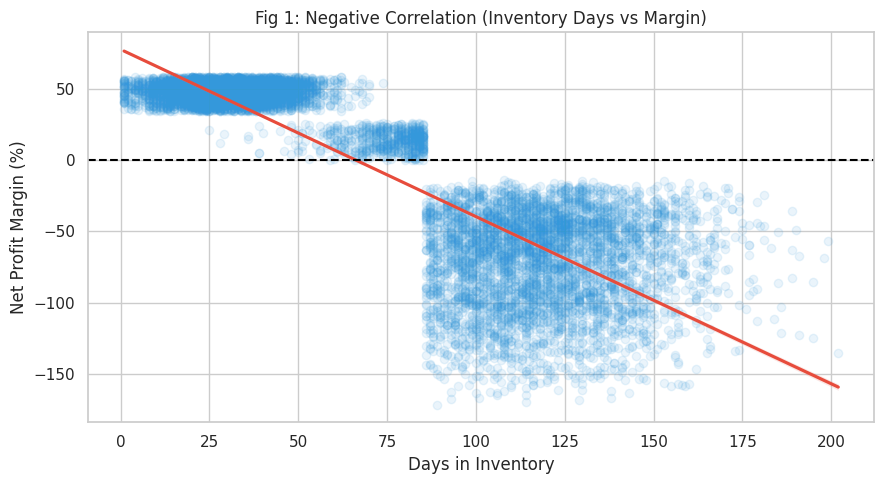

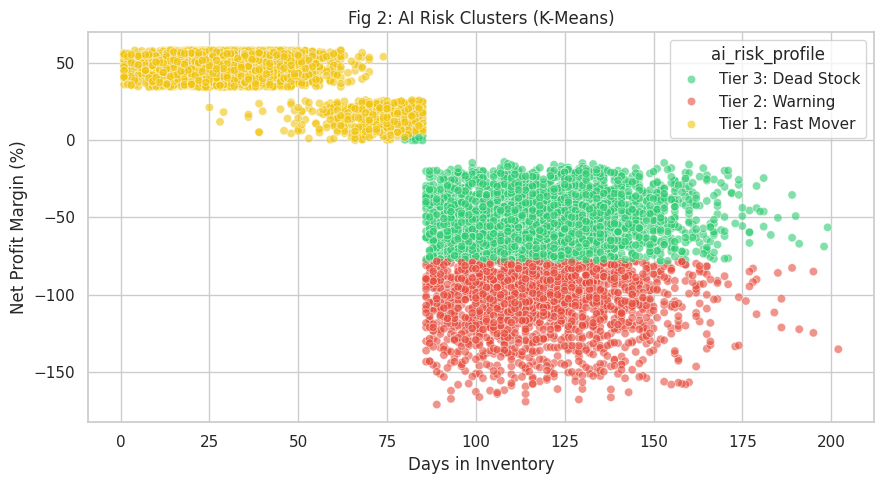

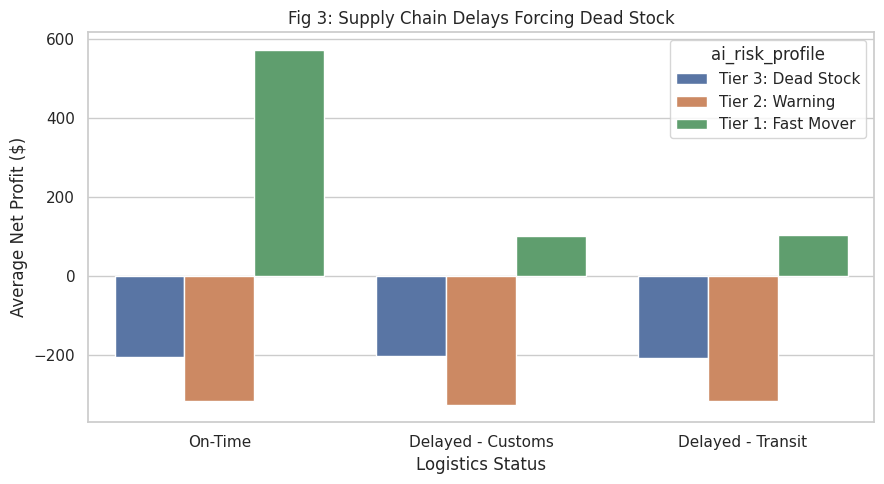

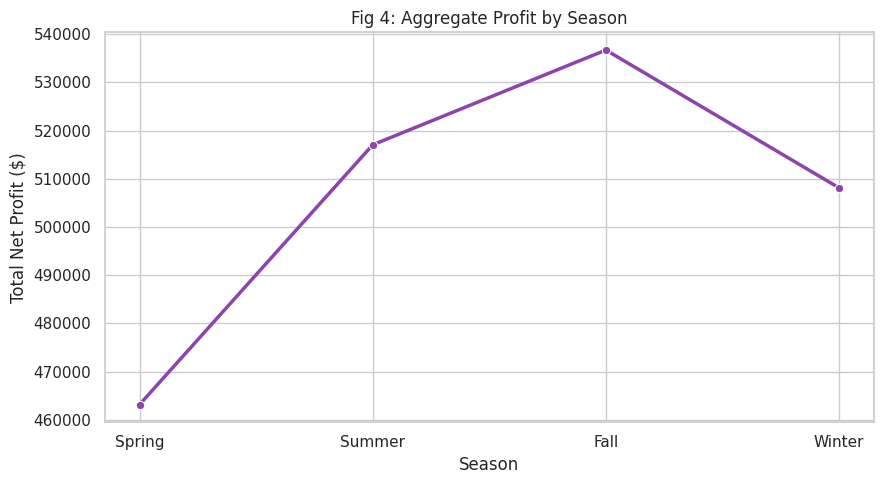

SUCCESS: 4 PNGs generated. Final dataset ready.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('2_sql_processed_data.csv')

# 2. Seasonality Mapping
df['order_date'] = pd.to_datetime(df['order_date'])
df['season'] = df['order_date'].dt.month.map({
    12:'Winter', 1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer', 9:'Fall', 10:'Fall', 11:'Fall'
})

# 3. AI Risk Clustering
X = df[['inventory_days', 'profit_margin_pct']].dropna()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['ai_cluster'] = kmeans.fit_predict(X)

cluster_map = {
    df.groupby('ai_cluster')['inventory_days'].mean().idxmin(): 'Tier 1: Fast Mover',
    df.groupby('ai_cluster')['inventory_days'].mean().idxmax(): 'Tier 3: Dead Stock',
}
for i in [0, 1, 2]:
    if i not in cluster_map: cluster_map[i] = 'Tier 2: Warning'
df['ai_risk_profile'] = df['ai_cluster'].map(cluster_map)

sns.set_theme(style="whitegrid")

# --- IMAGE 1: CORRELATION GRAPH ---
plt.figure(figsize=(9, 5))
sns.regplot(x='inventory_days', y='profit_margin_pct', data=df,
            scatter_kws={'alpha':0.1, 'color':'#3498db'}, line_kws={'color':'#e74c3c'})
plt.title('Fig 1: Negative Correlation (Inventory Days vs Margin)')
plt.ylabel('Net Profit Margin (%)')
plt.xlabel('Days in Inventory')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('1_correlation_graph.png', dpi=300)
plt.show()

# --- IMAGE 2: AI RISK CLUSTERING ---
plt.figure(figsize=(9, 5))
sns.scatterplot(x='inventory_days', y='profit_margin_pct', hue='ai_risk_profile',
                palette=['#2ecc71', '#e74c3c', '#f1c40f'], data=df, alpha=0.6)
plt.title('Fig 2: AI Risk Clusters (K-Means)')
plt.ylabel('Net Profit Margin (%)')
plt.xlabel('Days in Inventory')
plt.tight_layout()
plt.savefig('2_risk_clusters.png', dpi=300)
plt.show()

# --- IMAGE 3: SUPPLY CHAIN IMPACT ---
plt.figure(figsize=(9, 5))
sns.barplot(x='supply_chain_status', y='net_profit', hue='ai_risk_profile', data=df, errorbar=None)
plt.title('Fig 3: Supply Chain Delays Forcing Dead Stock')
plt.ylabel('Average Net Profit ($)')
plt.xlabel('Logistics Status')
plt.tight_layout()
plt.savefig('3_supply_chain_impact.png', dpi=300)
plt.show()

# --- IMAGE 4: SEASONAL TRENDS ---
plt.figure(figsize=(9, 5))
seasonal_profit = df.groupby('season')['net_profit'].sum().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
sns.lineplot(x=seasonal_profit.index, y=seasonal_profit.values, marker="o", color="#8e44ad", linewidth=2.5)
plt.title('Fig 4: Aggregate Profit by Season')
plt.ylabel('Total Net Profit ($)')
plt.xlabel('Season')
plt.tight_layout()
plt.savefig('4_seasonal_trend.png', dpi=300)
plt.show()

# Export Final Data
df.to_csv('3_final_master_dataset.csv', index=False)
print("SUCCESS: 4 PNGs generated. Final dataset ready.")